# COSC202 Project Testing Notebook

This notebook loads the saved final model and preprocessing pipeline from the main project notebook. It is designed for demo day, where raw unseen data can be loaded, preprocessed in the same way as training data, and passed directly to the saved model for prediction.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

## Step 1: Load the saved model and preprocessing bundle

These two files were created in the main project notebook. The model file stores the tuned Random Forest, and the deployment bundle stores the learned preprocessing objects and metadata needed to preprocess raw unseen data.

In [9]:
# Path of the saved model and deployment bundle
model_path = 'final_random_forest_model.pkl'
bundle_path = 'rf_deployment_bundle.pkl'

# Load the saved model and deployment bundle
with open(model_path, 'rb') as f:
    final_model = pickle.load(f)

with open(bundle_path, 'rb') as f:
    deployment_bundle = pickle.load(f)

print('Loaded model from:', model_path)
print('Loaded deployment bundle from:', bundle_path)

Loaded model from: final_random_forest_model.pkl
Loaded deployment bundle from: rf_deployment_bundle.pkl


## Step 2: Choose the unseen raw data file

On demo day, update the file path below to the unseen dataset given by the instructor. The notebook expects raw data in the same general format as the original project dataset.

In [13]:
# Replace with the actual path of unseen dataset
UNSEEN_PATH = 'data/sample_dataset.csv'

In [14]:
# Load the unseen data
unseen_data_path = UNSEEN_PATH
raw_df = pd.read_csv(unseen_data_path)

print('Loaded raw unseen data from:', unseen_data_path)
print('Shape:', raw_df.shape)
raw_df.head()

Loaded raw unseen data from: data/sample_dataset.csv
Shape: (999, 33)


,Started On Date,Started On Time,Completed On Date,Completed On Time,Distance Travelled,End Location Lat,End Location Long,Driver Rating,Rider Rating,Start Zip Code,...,AWND,GustSpeed2,Fog,HeavyFog,Thunder,ID,Holiday,Weekend,cancelled,Number of rides that day
0,04/06/2016,8:34:52,04/06/2016,8:35:56,285,30.27,-97.75,5.0,5,-1,...,4.9,13.000000,1,0,0,2399,0,1,1,1
1,04/06/2016,8:45:01,04/06/2016,8:51:15,1029,30.27,-97.74,5.0,5,-1,...,4.9,13.000000,1,0,0,2399,0,1,0,2
2,04/06/2016,9:18:49,04/06/2016,9:27:32,8459,38.68,-121.04,5.0,5,-1,...,NaN,13.000000,1,0,0,1557,0,1,0,1
3,04/06/2016,10:50:12,04/06/2016,10:51:49,443,38.68,-121.04,5.0,5,-1,...,4.9,12.540277,1,0,0,1557,0,1,1,2
4,04/06/2016,12:16:02,04/06/2016,12:17:57,568,38.68,-121.04,3.0,5,-1,...,4.9,13.000000,1,0,0,1557,0,1,0,3


## Step 3: Apply the same preprocessing pipeline

This function follows the same preprocessing logic used in the main project notebook. It cleans placeholder and impossible values, creates the time-based features, groups rare car models into `Other`, applies the saved imputers and encoder, and returns the final model-ready feature set.

In [15]:
# Function to preprocess raw data using the saved deployment bundle
def preprocess_raw_data(df, bundle):
    df = df.copy()

    # Unpack the deployment bundle
    imputer = bundle['imputer']
    categorical_imputer = bundle['categorical_imputer']
    encoder = bundle['encoder']
    categorical_cols = list(categorical_imputer.feature_names_in_)
    numeric_cols = list(imputer.feature_names_in_)
    model_numeric_cols = bundle['model_numeric_cols']
    encoded_feature_names = bundle['encoded_feature_names']
    all_feature_names = bundle['all_feature_names']
    kept_model_values = set(bundle['kept_model_values'])

    # Replace known placeholder values with missing values
    placeholder_cols = ['Distance Travelled', 'Driver Rating', 'Rider Rating', 'Start Zip Code', 'End Zip Code']
    for col in placeholder_cols:
        if col in df.columns:
            df[col] = df[col].replace(-1, np.nan)

    # Replace impossible values with missing values, same as main notebook logic
    if 'PRCP' in df.columns:
        df.loc[df['PRCP'] < 0, 'PRCP'] = np.nan
    if 'AWND' in df.columns:
        df.loc[df['AWND'] < 0, 'AWND'] = np.nan
    if 'GustSpeed2' in df.columns:
        df.loc[df['GustSpeed2'] < 0, 'GustSpeed2'] = np.nan
    if 'Year' in df.columns:
        df.loc[(df['Year'] > 2026) | (df['Year'] < 1990), 'Year'] = np.nan
    if 'Distance Travelled' in df.columns:
        df.loc[df['Distance Travelled'] > 200000, 'Distance Travelled'] = np.nan
    if 'TMAX' in df.columns and 'TMIN' in df.columns:
        invalid_temp = df['TMAX'] < df['TMIN']
        df.loc[invalid_temp, ['TMAX', 'TMIN']] = np.nan

    # Create time-based features
    for col in ['Started On Date', 'Started On Time']:
        if col not in df.columns:
            df[col] = np.nan

    started_dt = pd.to_datetime(
        df['Started On Date'].astype(str) + ' ' + df['Started On Time'].astype(str),
        errors='coerce'
    )
    df['hour'] = started_dt.dt.hour
    df['day_of_week'] = started_dt.dt.dayofweek

    # Drop columns that should not be used for prediction
    cols_to_drop = ['Started On Date', 'Started On Time', 'Completed On Date', 'Completed On Time', 'ID', 'Start Zip Code', 'End Zip Code']
    for col in cols_to_drop:
        if col in df.columns:
            df = df.drop(columns=col)

    # Group unseen or rare car models into Other
    if 'Model' not in df.columns:
        df['Model'] = 'Other'
    else:
        df['Model'] = df['Model'].apply(lambda x: x if x in kept_model_values else 'Other')

    # Make sure all expected feature columns exist before imputation
    expected_cols = list(numeric_cols) + list(categorical_cols)
    for col in expected_cols:
        if col not in df.columns:
            df[col] = np.nan

    # Apply the saved imputers using the same feature order as training
    numeric_df = pd.DataFrame(imputer.transform(df[numeric_cols]), columns=numeric_cols, index=df.index)
    categorical_df = pd.DataFrame(
        categorical_imputer.transform(df[categorical_cols]),
        columns=categorical_cols,
        index=df.index
    )

    # Apply the saved encoder and combine the final features
    encoded_df = pd.DataFrame(
        encoder.transform(categorical_df),
        columns=encoded_feature_names,
        index=df.index
    )

    # Combine numeric and encoded features into the final dataframe
    final_df = pd.concat([numeric_df[model_numeric_cols], encoded_df], axis=1)
    final_df = final_df.reindex(columns=all_feature_names, fill_value=0)

    return final_df

In [ ]:
# Preprocess the raw unseen data using the saved deployment bundle & helper function
X_unseen = preprocess_raw_data(raw_df, deployment_bundle)

print('Processed feature shape:', X_unseen.shape)
X_unseen.head()    

Processed feature shape: (999, 183)


,End Location Lat,End Location Long,Driver Rating,Rider Rating,Surge Factor,Start Location Long,Start Location Lat,Year,Rating,PRCP,...,Model_Suburban,Model_Tahoe,Model_Taurus,Model_Town Car,Model_Town and Country,Model_Traverse,Model_Tucson,Model_Tundra,Model_Versa,Model_xB
0,30.27,-97.75,5.0,5.0,0.0,-97.75,30.27,2013.0,5.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,30.27,-97.74,5.0,5.0,0.0,-97.75,30.27,2013.0,5.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,38.68,-121.04,5.0,5.0,0.0,-121.07,38.65,2013.0,5.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,38.68,-121.04,5.0,5.0,0.0,-121.04,38.68,2013.0,5.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,38.68,-121.04,3.0,5.0,0.0,-121.04,38.68,2013.0,5.0,0.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 4: Predict on the unseen data

The saved Random Forest model can now predict directly on the processed unseen data. If the unseen dataset also contains the true `cancelled` labels, the notebook will additionally compute metrics and show a confusion matrix.

In [17]:
# Make predictions on the unseen data using the loaded model
predictions = final_model.predict(X_unseen)
results_df = raw_df.copy()
results_df['predicted_cancelled'] = predictions

# Print prediction counts
print('Prediction counts:')
print(results_df['predicted_cancelled'].value_counts())
results_df.head()

Prediction counts:
0    952
1     47
Name: predicted_cancelled, dtype: int64


,Started On Date,Started On Time,Completed On Date,Completed On Time,Distance Travelled,End Location Lat,End Location Long,Driver Rating,Rider Rating,Start Zip Code,...,GustSpeed2,Fog,HeavyFog,Thunder,ID,Holiday,Weekend,cancelled,Number of rides that day,predicted_cancelled
0,04/06/2016,8:34:52,04/06/2016,8:35:56,285,30.27,-97.75,5.0,5,-1,...,13.000000,1,0,0,2399,0,1,1,1,0
1,04/06/2016,8:45:01,04/06/2016,8:51:15,1029,30.27,-97.74,5.0,5,-1,...,13.000000,1,0,0,2399,0,1,0,2,0
2,04/06/2016,9:18:49,04/06/2016,9:27:32,8459,38.68,-121.04,5.0,5,-1,...,13.000000,1,0,0,1557,0,1,0,1,0
3,04/06/2016,10:50:12,04/06/2016,10:51:49,443,38.68,-121.04,5.0,5,-1,...,12.540277,1,0,0,1557,0,1,1,2,0
4,04/06/2016,12:16:02,04/06/2016,12:17:57,568,38.68,-121.04,3.0,5,-1,...,13.000000,1,0,0,1557,0,1,0,3,0


Evaluation metrics on the unseen data:
Accuracy : 0.968
Precision: 0.4681
Recall   : 0.7586
F1-score : 0.5789


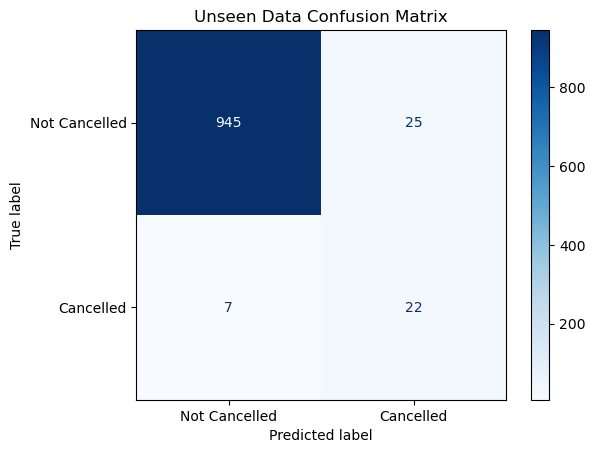

In [18]:
# If the true 'cancelled' column exists in the raw unseen data, evaluate the predictions
if 'cancelled' in raw_df.columns:
    y_true = raw_df['cancelled']

    # Calculate evaluation metrics
    test_accuracy = accuracy_score(y_true, predictions)
    test_precision = precision_score(y_true, predictions, zero_division=0)
    test_recall = recall_score(y_true, predictions, zero_division=0)
    test_f1 = f1_score(y_true, predictions, zero_division=0)

    print('Evaluation metrics on the unseen data:')
    print('Accuracy :', round(test_accuracy, 4))
    print('Precision:', round(test_precision, 4))
    print('Recall   :', round(test_recall, 4))
    print('F1-score :', round(test_f1, 4))

    # Confusion matrix
    cm_unseen = confusion_matrix(y_true, predictions)
    ConfusionMatrixDisplay(cm_unseen, display_labels=['Not Cancelled', 'Cancelled']).plot(cmap='Blues')
    plt.title('Unseen Data Confusion Matrix')
    plt.show()
else:
    print('No true cancelled column found, so only predictions are shown.')

### Testing Notebook Summary

This notebook is independent from the training notebook. It loads the saved Random Forest model and preprocessing bundle, applies the same preprocessing pipeline to raw unseen data, and generates predictions instantly. If the unseen data contains the true labels, it also reports evaluation metrics and a confusion matrix.